In [ ]:
# Importing Libraries
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.optimize import minimize
import random
from deap import base, creator, tools, algorithms
from datetime import timedelta
import subprocess


In [114]:
# Get S&P 100 tickers from Wikipedia
wiki_url = 'https://en.wikipedia.org/wiki/S%26P_100'
tables = pd.read_html(wiki_url)

# The table with tickers is the 3rd table
sp100_df = tables[2]  

# Extract ticker symbols and fix known issues
sp100_tickers = sp100_df['Symbol'].tolist()
sp100_tickers = ['BRK-B' if x == 'BRK.B' else x for x in sp100_tickers]

# Download stock data
start_date = "2019-01-01"
end_date = "2025-03-01"

print("Downloading stock data for S&P 100 companies...")
data = yf.download(sp100_tickers, start=start_date, end=end_date, group_by='ticker', auto_adjust=True)
print("Download complete!")

[*********************100%***********************]  101 of 101 completed

Download complete!


This code retrieves the list of S&P 100 company tickers from Wikipedia and downloads their historical stock data using the yfinance library. The data collected spans from January 2019 to March 2025 and includes adjustments for dividends and splits.

In [115]:
# Extract closing prices into a clean dataframe
close_prices = pd.DataFrame()
for ticker in data.columns.levels[0]:
    if 'Close' in data[ticker].columns:
        close_prices[ticker] = data[ticker]['Close']

# Drop rows with missing data
close_prices.dropna(inplace=True)

# Clean data to CSV
close_prices.index = pd.to_datetime(close_prices.index)
close_prices.sort_index(inplace=True)
close_prices.to_csv("sp100_clean_close.csv")
print("Cleaned closing prices saved to 'sp100_clean_close.csv'")

Cleaned closing prices saved to 'sp100_clean_close.csv'


C:\Users\moham\AppData\Local\Temp\ipykernel_15512\2620644385.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  close_prices[ticker] = data[ticker]['Close']


This block filters out the 'Close' prices from the downloaded dataset, ensures all missing values are removed, sorts by date and saves the cleaned data to a CSV file for later use.

In [116]:
# Load the cleaned CSV file
close_prices = pd.read_csv("sp100_clean_close.csv", index_col=0, parse_dates=True)
print(close_prices.head())

# Check for missing values
missing = close_prices.isna().sum().sum()
print(f"Total missing values: {missing}")

# Show date range and dimensions
print(f"Date range: {close_prices.index.min().date()} to {close_prices.index.max().date()}")
print(f"Shape: {close_prices.shape[0]} days x {close_prices.shape[1]} stocks")

# Save final clean data to csv
close_prices.to_csv("sp100_clean_final.csv")
print("Cleaned closing prices saved to 'sp100_clean_final.csv'")

                  AAPL       ABBV         ABT         ACN        ADBE  \
Date                                                                    
2020-09-30  112.926208  72.906448  100.451843  212.520233  490.429993   
2020-10-01  113.881775  72.531898  100.276466  211.758499  499.510010   
2020-10-02  110.205673  71.682877   98.301208  209.144196  478.989990   
2020-10-05  113.599007  73.189468  100.202637  210.169220  486.470001   
2020-10-06  110.342171  71.491440   98.070480  207.216354  478.980011   

                  AIG        AMD        AMGN         AMT        AMZN  ...  \
Date                                                                  ...   
2020-09-30  24.766953  81.989998  220.906967  213.099487  157.436493  ...   
2020-10-01  24.937889  84.860001  221.976074  213.469742  161.063004  ...   
2020-10-02  25.387707  81.800003  213.301834  214.483536  156.250000  ...   
2020-10-05  26.134405  86.150002  222.514938  214.509979  159.960007  ...   
2020-10-06  26.071430  84.

This cell loads the previously saved cleaned dataset and performs a quick inspection of its structure. It checks for any missing values and prints out the number of trading days and stocks covered. It also saves the finalized clean data under a new name for standardization.

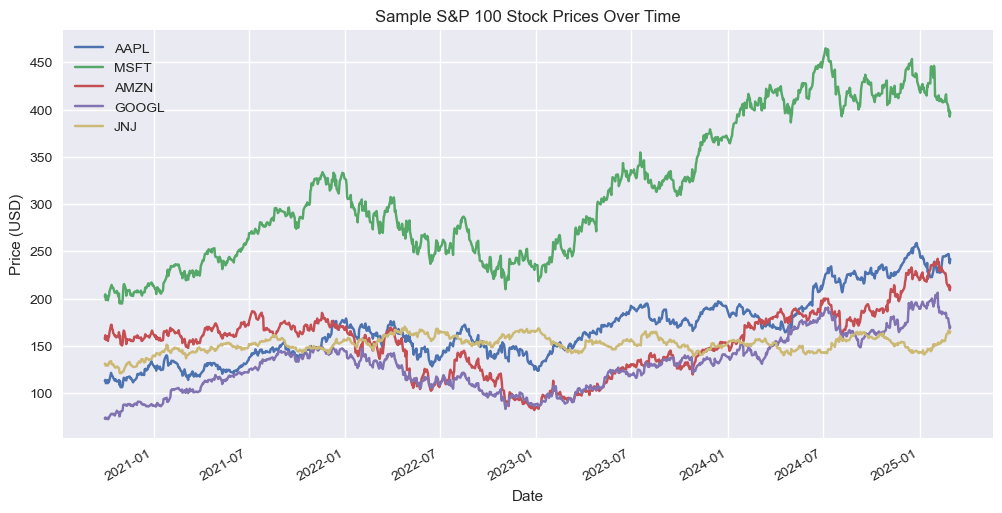

In [117]:
# Plot a few stock prices over time
close_prices = pd.read_csv("sp100_clean_final.csv", index_col=0, parse_dates=True)

sample_stocks = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'JNJ']
close_prices[sample_stocks].plot(figsize=(12, 6))
plt.title("Sample S&P 100 Stock Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.show()

This visualization provides a quick glance at how the stock prices of selected S&P 100 companies like Apple, Google, etc. have evolved over the analyzed period. It helps in understanding stock volatility and overall trends.

In [118]:
# Data Characteristics
summary_stats = close_prices.describe()
print("Summary statistics:")
print(summary_stats)


Summary statistics:
              AAPL         ABBV          ABT          ACN         ADBE  \
count  1109.000000  1109.000000  1109.000000  1109.000000  1109.000000   
mean    166.632912   134.739979   107.860869   301.557096   485.006023   
std      34.857759    31.494595     8.703871    41.666876    92.469839   
min     106.061501    67.909058    87.963768   201.976273   275.200012   
25%     141.035004   103.420647   101.564560   270.674957   426.750000   
50%     163.253601   136.905502   107.245918   301.856140   488.070007   
75%     185.744812   156.003204   113.332901   330.655090   549.929993   
max     258.735504   209.029999   138.009995   398.250000   688.369995   

               AIG          AMD         AMGN          AMT         AMZN  ...  \
count  1109.000000  1109.000000  1109.000000  1109.000000  1109.000000  ...   
mean     56.515385   111.717196   240.231997   206.918853   153.178573  ...   
std      12.500698    32.166138    38.765140    26.248796    33.974722  ... 

This cell calculates summary statistics such as mean, standard deviation, min, max and quartiles for each stock. These metrics help us understand the distribution and variability of stock prices across the S&P 100.

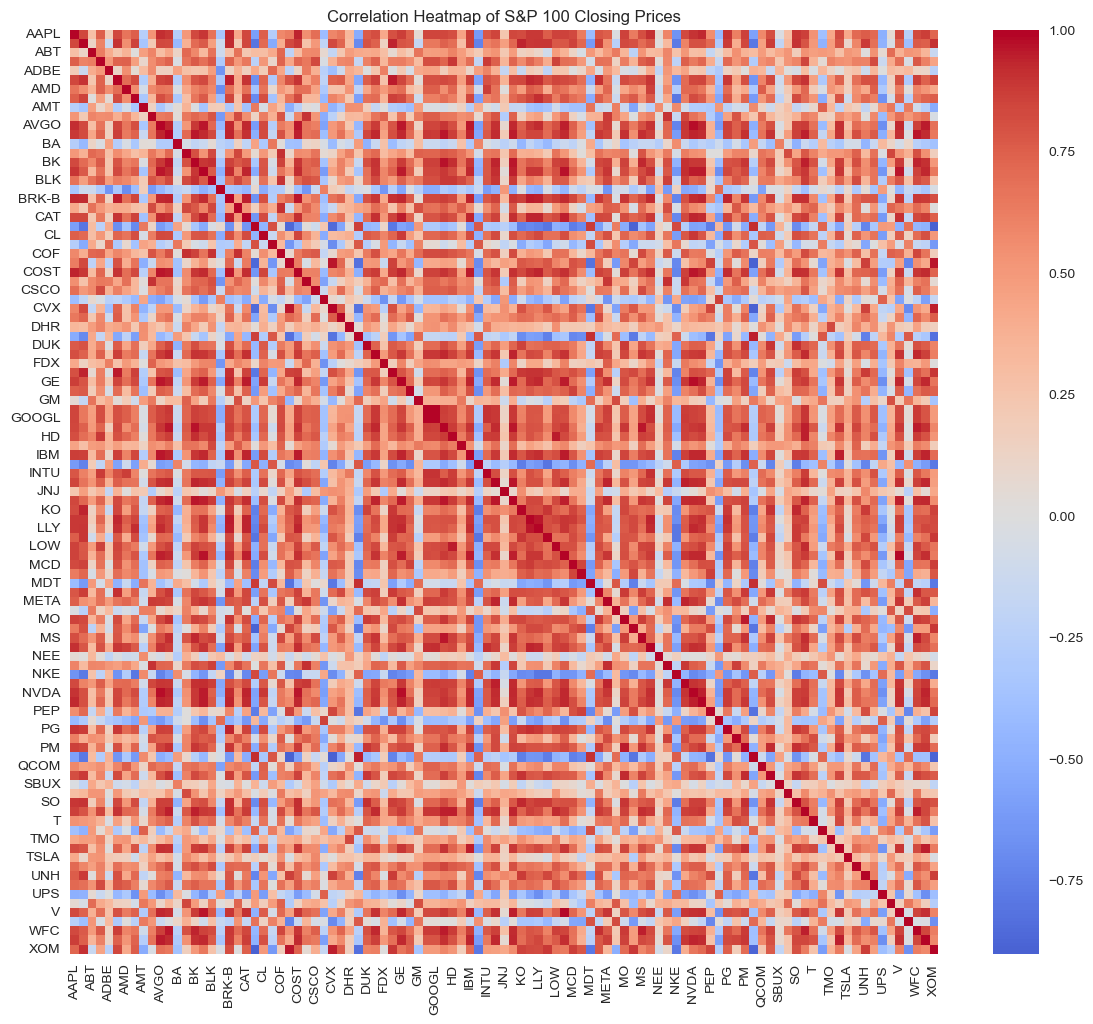

In [119]:
# Correlation heatmap
plt.figure(figsize=(14, 12))
correlation_matrix = close_prices.corr()
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap of S&P 100 Closing Prices")
plt.show()

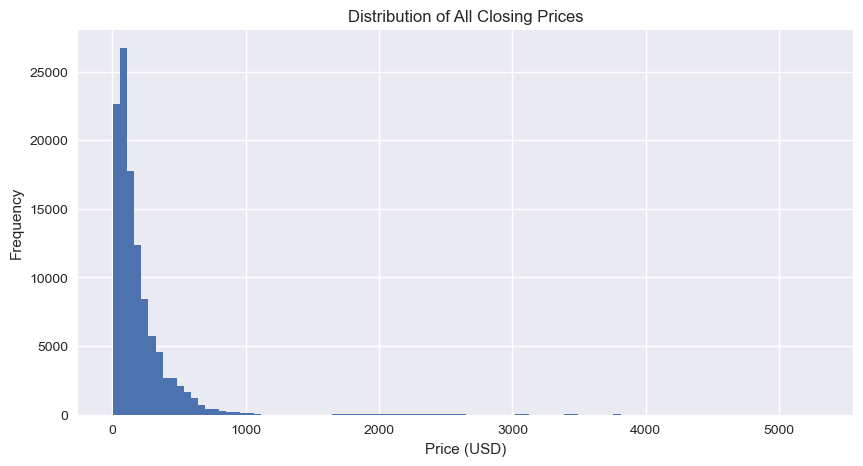

In [120]:
# Histogram of closing prices
close_prices.stack().hist(bins=100, figsize=(10, 5))
plt.title("Distribution of All Closing Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Frequency")
plt.show()

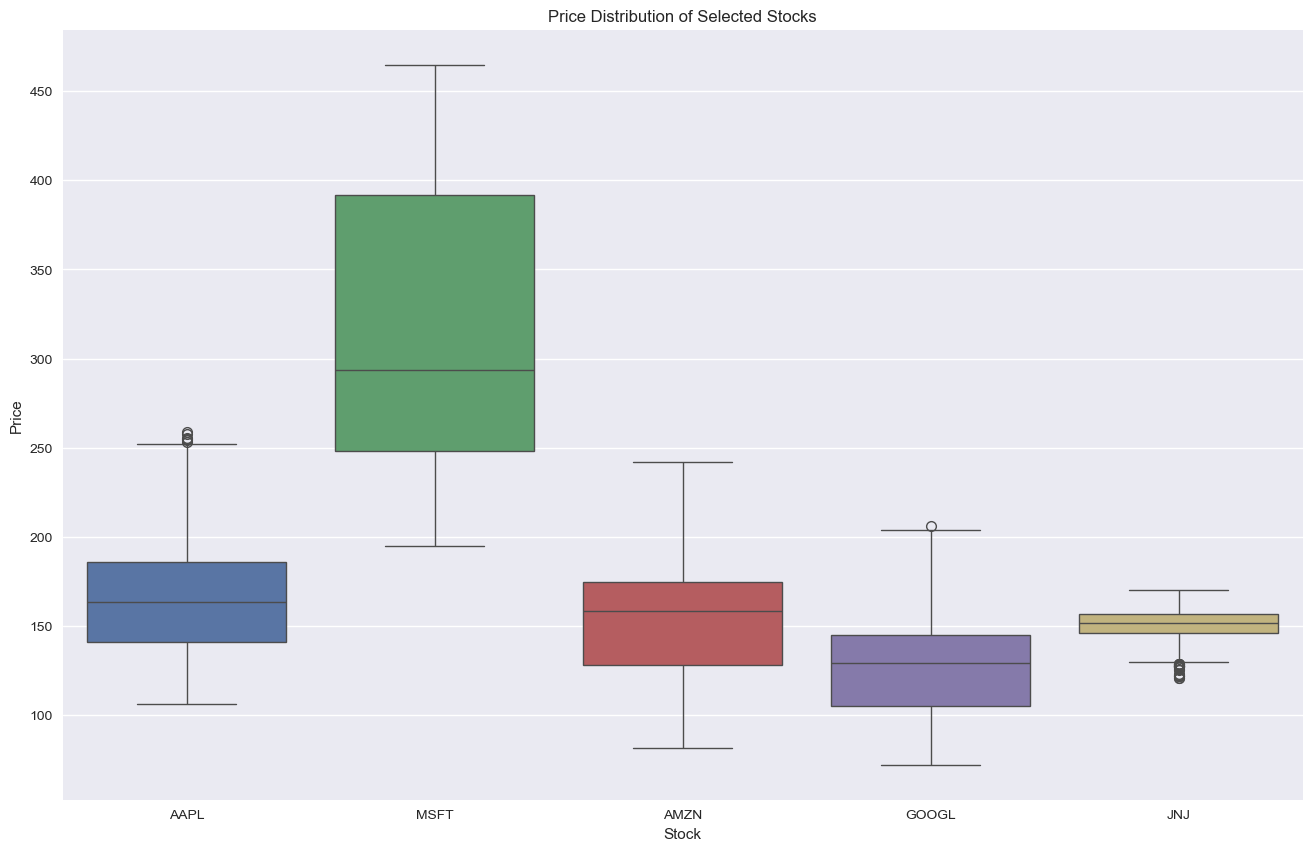

In [ ]:
# Boxplot of sample stocks of closing prices
plt.figure(figsize=(16, 10))
sns.boxplot(data=close_prices[sample_stocks])
plt.title("Price Distribution of Selected Stocks")
plt.xlabel("Stock")
plt.ylabel("Price")
plt.show()

The boxplot visualizes the distribution of prices for selected stocks. It highlights the median, quartiles and potential outliers offering insights into the range and skewness of the price data for each stock.

In [122]:
# Calculate daily percentage returns
returns = close_prices.pct_change().dropna()
print(returns.head())

# Show date range and shape
print(f"Date range: {returns.index.min().date()} to {returns.index.max().date()}")
print(f"Shape: {returns.shape[0]} days x {returns.shape[1]} stocks")

# Save returns for csv
returns.to_csv("sp100_daily_returns.csv")
print("Daily returns saved to 'sp100_daily_returns.csv'")


                AAPL      ABBV       ABT       ACN      ADBE       AIG  \
Date                                                                     
2020-10-01  0.008462 -0.005137 -0.001746 -0.003584  0.018514  0.006902   
2020-10-02 -0.032280 -0.011705 -0.019698 -0.012346 -0.041080  0.018038   
2020-10-05  0.030791  0.021017  0.019343  0.004901  0.015616  0.029412   
2020-10-06 -0.028670 -0.023200 -0.021278 -0.014050 -0.015397 -0.002410   
2020-10-07  0.016967  0.013739  0.014023  0.014068  0.029584  0.020014   

                 AMD      AMGN       AMT      AMZN  ...       TXN       UNH  \
Date                                                ...                       
2020-10-01  0.035004  0.004840  0.001737  0.023035  ...  0.014847  0.004170   
2020-10-02 -0.036059 -0.039077  0.004749 -0.029883  ... -0.026361 -0.003482   
2020-10-05  0.053178  0.043193  0.000123  0.023744  ...  0.021192  0.019777   
2020-10-06 -0.019385 -0.012968 -0.009534 -0.031020  ... -0.001596 -0.011630   
2020-10

APPROACH 1 - PYTHON - BASED GENETIC ALGORITHM OPTIMIZATION

This step computes daily percentage returns from the closing prices for all stocks. It removes rows with missing values and saves the result to a CSV for later use in portfolio optimization and comparison.

In [123]:
# Python-Based Tracking Error Minimization using SciPy

# Load daily returns from CSV
returns = pd.read_csv("sp100_daily_returns.csv", index_col=0, parse_dates=True)

# Select top q stocks by picking first 20
q = 20
top_q_stocks = returns.columns[:q]

# Extract returns of those q stocks
selected_returns = returns[top_q_stocks]

# Download S&P 100 ETF (OEF) returns for the same period
etf_data = yf.download("OEF", start=returns.index.min(), end=returns.index.max(), auto_adjust=True)
etf_returns = etf_data["Close"].pct_change().dropna()

# Align both datasets and drop remaining NaNs
common_index = selected_returns.index.intersection(etf_returns.index)
aligned_returns = selected_returns.loc[common_index].copy()
aligned_returns["OEF"] = etf_returns.loc[common_index]
aligned_returns.dropna(inplace=True)

# Separate ETF and stock returns
etf_returns = aligned_returns["OEF"]
selected_returns = aligned_returns.drop(columns=["OEF"])


[*********************100%***********************]  1 of 1 completed


This block loads the daily returns and selects a subset of 20 stocks (top q). It then downloads benchmark ETF (OEF) returns and aligns both datasets by date to prepare for optimization. This ensures the inputs are synchronized for accurate comparison.

In [124]:
# Define tracking error function
def tracking_error(weights, portfolio_returns, benchmark_returns):
    portfolio_perf = portfolio_returns @ weights
    return np.sqrt(np.mean((portfolio_perf - benchmark_returns) ** 2))

# Set up and solve the optimization problem
n = len(top_q_stocks)
initial_weights = np.ones(n) / n
bounds = [(0, 1)] * n
constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}

# Run the optimizer
result = minimize(tracking_error, initial_weights, args=(selected_returns, etf_returns), method='SLSQP', bounds=bounds, constraints=constraints)
print(f"Tracking Error: {result.fun:.6f}")
print("Optimized Weights:")
for stock, weight in zip(top_q_stocks, result.x):
    print(f"{stock}: {weight:.4f}")

Tracking Error: 0.003098
Optimized Weights:
AAPL: 0.1865
ABBV: 0.0511
ABT: 0.0526
ACN: 0.0528
ADBE: 0.0482
AIG: 0.0023
AMD: 0.0295
AMGN: 0.0286
AMT: 0.0128
AMZN: 0.1080
AVGO: 0.0805
AXP: 0.0113
BA: 0.0090
BAC: 0.0257
BK: 0.0247
BKNG: 0.0298
BLK: 0.0194
BMY: 0.0520
BRK-B: 0.1453
C: 0.0300


This section defines the optimization objective: minimizing the tracking error between the constructed portfolio and the ETF. It then uses the Sequential Least Squares Programming (SLSQP) method to compute the optimal weights. The result gives a low tracking error portfolio using the top 20 selected stocks.

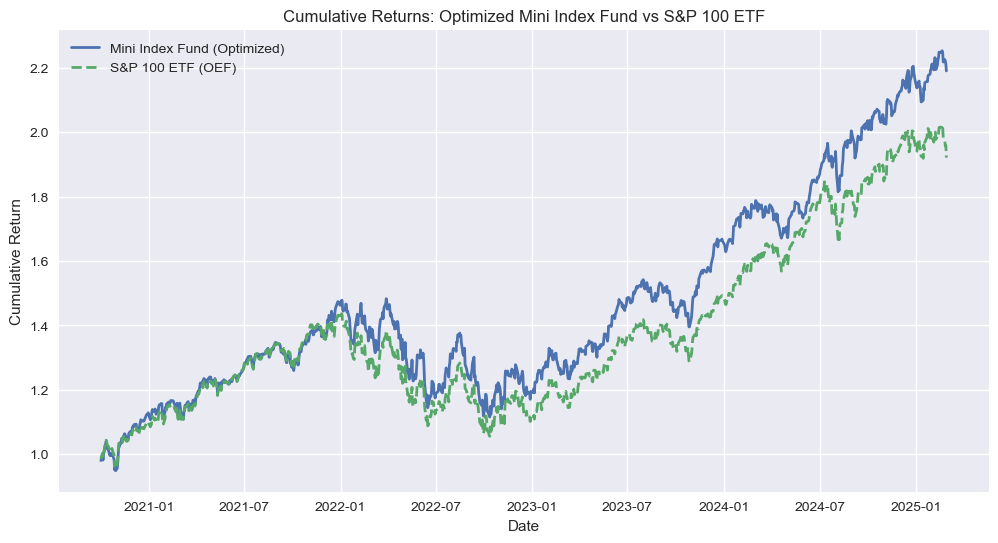

In [125]:
# Evaluate Optimized Portfolio and Visualize Performance

# Recalculate portfolio returns using optimized weights
portfolio_returns = selected_returns @ result.x

# Compute cumulative returns for both portfolio and ETF
portfolio_cum_returns = (1 + portfolio_returns).cumprod()
etf_cum_returns = (1 + etf_returns).cumprod()

# Plot the cumulative returns of portfolio vs ETF
plt.figure(figsize=(12, 6))
plt.plot(portfolio_cum_returns, label='Mini Index Fund (Optimized)', linewidth=2)
plt.plot(etf_cum_returns, label='S&P 100 ETF (OEF)', linestyle='--', linewidth=2)
plt.title('Cumulative Returns: Optimized Mini Index Fund vs S&P 100 ETF')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.show()


In [126]:
# Experimenting with different portfolio sizes (q)

# Load daily returns for all S&P 100 stocks
returns = pd.read_csv("sp100_daily_returns.csv", index_col=0, parse_dates=True)

# Download benchmark ETF returns
etf_data = yf.download("OEF", start=returns.index.min(), end=returns.index.max(), auto_adjust=True)
etf_returns = etf_data["Close"].pct_change().dropna()

# List of values of q to test (how many stocks in the portfolio)
q_list = [10, 20, 30]
tracking_errors = []
portfolios = {}

# Optimization loop for each q
for q in q_list:
    print(f"\nRunning optimization for q = {q} stocks")

    # Pick first q stocks
    tickers = returns.columns[:q]
    selected_returns = returns[tickers]

    # Align ETF and stock returns
    common_index = selected_returns.index.intersection(etf_returns.index)
    aligned = selected_returns.loc[common_index].copy()
    aligned["OEF"] = etf_returns.loc[common_index]
    aligned.dropna(inplace=True)

    portfolio_returns = aligned.drop(columns=["OEF"])
    benchmark_returns = aligned["OEF"]

    # Define tracking error function
    def tracking_error(weights):
        portfolio_perf = portfolio_returns @ weights
        return np.sqrt(np.mean((portfolio_perf - benchmark_returns) ** 2))

    # Optimization setup
    n = len(tickers)
    init_w = np.ones(n) / n
    bounds = [(0, 1)] * n
    constraint = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}

    # Solve Optimization
    result = minimize(tracking_error, init_w, method='SLSQP', bounds=bounds, constraints=constraint)

    tracking_errors.append(result.fun)
    portfolios[q] = {'weights': result.x,
        'tickers': tickers,
        'tracking_error': result.fun,
        'portfolio_returns': portfolio_returns @ result.x,
        'benchmark_returns': benchmark_returns}

    print(f"Tracking Error for q = {q}: {result.fun:.6f}")


[*********************100%***********************]  1 of 1 completed



Running optimization for q = 10 stocks
Tracking Error for q = 10: 0.004116

Running optimization for q = 20 stocks
Tracking Error for q = 20: 0.003098

Running optimization for q = 30 stocks
Tracking Error for q = 30: 0.002759


This section runs the optimization process for different values of q (10, 20 and 30 stocks). It calculates and compares the tracking error for each case and visualizes how performance changes as the number of portfolio assets increases.

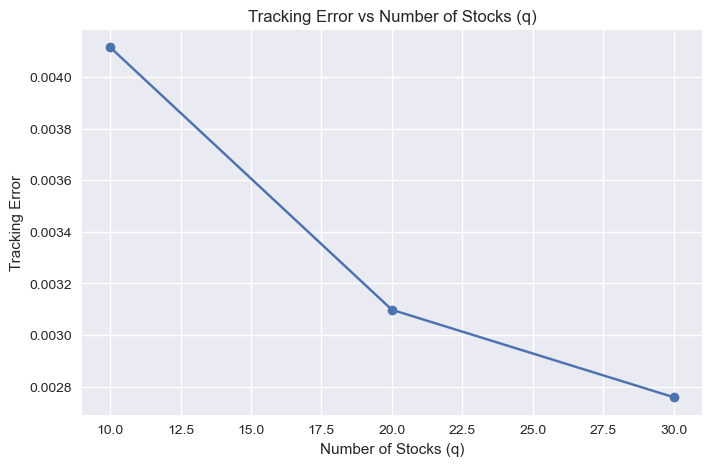

In [127]:
# Plot tracking error vs q
plt.figure(figsize=(8, 5))
plt.plot(q_list, tracking_errors, marker='o')
plt.title("Tracking Error vs Number of Stocks (q)")
plt.xlabel("Number of Stocks (q)")
plt.ylabel("Tracking Error")
plt.show()

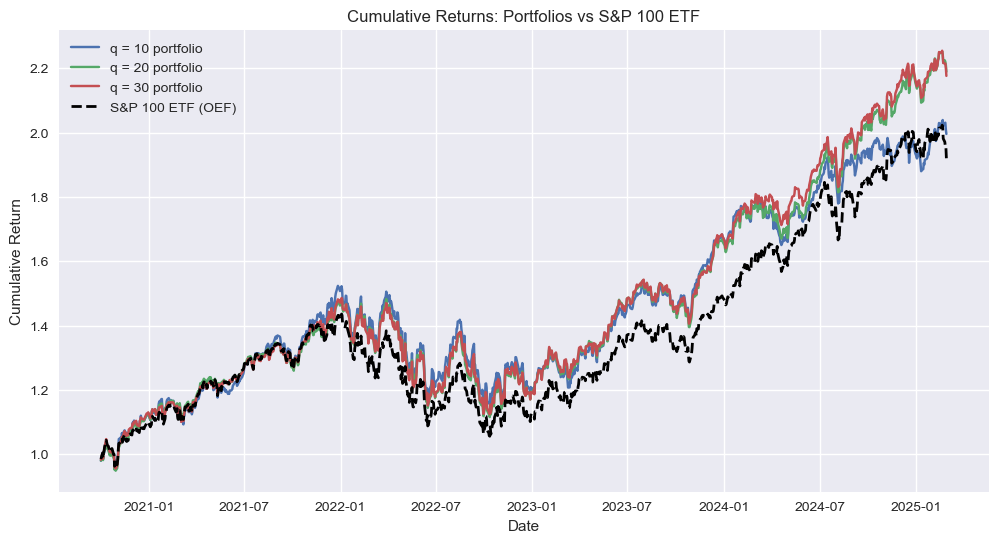

In [128]:
# Visual Comparison of ETF vs Portfolio Cumulative Returns

# Plot cumulative returns of portfolio vs ETF
plt.figure(figsize=(12, 6))

for q in [10, 20, 30]:
    port_returns = portfolios[q]['portfolio_returns']
    cum_returns = (1 + port_returns).cumprod()
    plt.plot(cum_returns, label=f'q = {q} portfolio')

# Plot the ETF's cumulative return
benchmark = portfolios[30]['benchmark_returns']  # All use same ETF
etf_cum = (1 + benchmark).cumprod()
plt.plot(etf_cum, label='S&P 100 ETF (OEF)', linestyle='--', linewidth=2, color='black')

plt.title('Cumulative Returns: Portfolios vs S&P 100 ETF')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.show()


In [129]:
# Prepare Daily Returns and Benchmark ETF Returns

# Load daily returns of all S&P 100 stocks from CSV
returns = pd.read_csv("sp100_daily_returns.csv", index_col=0, parse_dates=True)

# Ensure the datetime index has no timezone info
returns.index = returns.index.tz_localize(None)

# Download S&P 100 ETF returns
etf_data = yf.download("OEF", start=returns.index.min(), end=returns.index.max(), auto_adjust=True)
etf_returns = etf_data["Close"].pct_change().dropna()
etf_returns = etf_returns.squeeze()
etf_returns.index = etf_returns.index.tz_localize(None)

# Align both datasets on shared dates
common_index = returns.index.intersection(etf_returns.index)
returns = returns.loc[common_index]
etf_returns = etf_returns.loc[common_index]


[*********************100%***********************]  1 of 1 completed


This cell loads daily returns and ETF returns again and aligns their dates. This is essential before applying the Genetic Algorithm to ensure both datasets are synchronized and free from missing values.

In [130]:
# Genetic Algorithm Setup

# Recreate DEAP creator classes
if "FitnessMin" in creator.__dict__:
    del creator.FitnessMin
if "Individual" in creator.__dict__:
    del creator.Individual

creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

# Toolbox to register GA functions (DEAP workflow)
toolbox = base.Toolbox()

# Number of stocks in portfolio (q = 20)
q = 20
num_assets = len(returns.columns)

# Function to Create One Individual
def create_individual():
    stock_indices = sorted(random.sample(range(num_assets), q))
    # Assign random weights using Dirichlet distribution
    weights = np.random.dirichlet(np.ones(q), 1)[0]
    return stock_indices + list(weights)

# Register GA components to the toolbox
toolbox.register("individual", tools.initIterate, creator.Individual, create_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Evaluation Function: Tracking Error
def evaluate(individual):
    stock_indices = individual[:q]
    weights = np.array(individual[q:])
    tickers = [returns.columns[int(i)] for i in stock_indices]

    try:
        port_returns = returns[tickers] @ weights
        diff = port_returns - etf_returns
        if diff.isnull().any():
            print("NaNs in return difference")
            return (np.inf,)
        te = np.sqrt(np.mean(diff ** 2))
        if np.isnan(te):
            print("Tracking error is NaN")
        return (te,)
    except Exception as e:
        print("Error evaluating:", e)
        return (np.inf,)

# Register GA operations
toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutShuffleIndexes, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)


This block sets up the DEAP framework to implement the Genetic Algorithm. It defines individuals as combinations of selected stock indices and weights, registers genetic operations (crossover, mutation, selection) and specifies the evaluation function using tracking error.

In [131]:
# Check stock returns and ETF returns
print("Returns shape:", returns.shape)
print("ETF shape:", etf_returns.shape)

Returns shape: (1106, 101)
ETF shape: (1106,)


Before running the GA, this cell checks if the stock and ETF return datasets are correctly shaped and aligned by dates. This verification step ensures that downstream calculations won’t run into misalignment issues.

In [132]:
# Run Genetic Algorithm

# Generate the initial population with 50 individuals
population = toolbox.population(n=50)

# Hall of Fame to keep track of the best individual
hof = tools.HallOfFame(1)
stats = tools.Statistics(lambda ind: ind.fitness.values[0])
stats.register("min", np.min)
stats.register("avg", np.mean)

# Run the Genetic Algorithm
population, log = algorithms.eaSimple(population, toolbox, cxpb=0.7, mutpb=0.2, ngen=50, stats=stats, halloffame=hof, verbose=True)


gen	nevals	min       	avg       
0  	50    	0.00438729	0.00649983
1  	41    	0.00464723	0.499854  
2  	35    	0.00469248	0.461384  
3  	39    	0.00460828	0.515786  
4  	33    	0.00405762	0.557212  
5  	44    	0.00372857	0.643653  
6  	40    	0.00372857	0.331622  
7  	41    	0.00341878	0.601245  
8  	38    	0.00394901	0.398408  
9  	46    	0.00390466	0.44909   
10 	44    	0.0040152 	0.469483  
11 	46    	0.00387413	0.68305   
12 	41    	0.00389726	0.539257  
13 	44    	0.00389726	0.603283  
14 	34    	0.00389726	0.318828  
15 	40    	0.00368912	0.283131  
16 	35    	0.00384782	0.256789  
17 	35    	0.00384782	0.381656  
18 	44    	0.00384782	0.35343   
19 	40    	0.00384782	0.495501  
20 	40    	0.00384782	0.453044  
21 	41    	0.00384782	0.40974   
22 	37    	0.00384782	0.760659  
23 	36    	0.00384782	0.672942  
24 	43    	0.00377136	0.552847  
25 	45    	0.00377136	0.740475  
26 	41    	0.00377136	0.498618  
27 	39    	0.0037689 	0.640635  
28 	35    	0.0037689 	0.514504  
29 	43    

This cell runs the Genetic Algorithm using DEAP’s eaSimple() function. The population evolves over 50 generations, using crossover, mutation, and selection to minimize the tracking error. The best solution is stored in the Hall of Fame.

In [133]:
# Extract and Evaluate Best Portfolio from Genetic Algorithm

# Save Best GA Portfolio
best_ga_individual = hof[0]
ga_indices = best_ga_individual[:q]

# The next 'q' values are the portfolio weights for those stocks
ga_weights = best_ga_individual[q:]

# Map stock indices to tickers
ga_tickers = returns.columns[ga_indices]
ga_port_returns = returns[ga_tickers] @ pd.Series(ga_weights, index=ga_tickers)
ga_tracking_error = ((ga_port_returns - etf_returns) ** 2).mean() ** 0.5
ga_correlation = ga_port_returns.corr(etf_returns)
ga_final_return = (1 + ga_port_returns).cumprod().iloc[-1]

print(f"GA Optimized -> TE: {ga_tracking_error:.6f}, Corr: {ga_correlation:.4f}, Final Return: {ga_final_return:.4f}")

GA Optimized -> TE: 0.003419, Corr: 0.9487, Final Return: 1.9144


This cell extracts the best solution from the GA and evaluates its performance. It calculates the tracking error, correlation with the ETF and final cumulative return of the GA-optimized portfolio.

In [155]:
# Extract and Display Best Portfolio from GA

# Extract best individual
best_ind = hof[0]
best_indices = best_ind[:q]
best_weights = best_ind[q:]
best_tickers = [returns.columns[int(i)] for i in best_indices]

print("Best Portfolio Found by Genetic Algorithm:")
for ticker, weight in zip(best_tickers, best_weights):
    print(f"{ticker}: {weight:.4f}")

Best Portfolio Found by Genetic Algorithm:
AAPL: 0.0379
AMT: 0.0282
AMZN: 0.0154
AXP: 0.0164
CSCO: 0.0155
CVS: 0.0209
GOOG: 0.0846
INTC: 0.0000
INTU: 0.0212
JPM: 0.0088
MSFT: 0.0606
NVDA: 0.0940
ORCL: 0.1181
PFE: 0.0058
NEE: 0.0043
NKE: 0.0519
PYPL: 0.0399
TGT: 0.0399
TXN: 0.0607
USB: 0.0565


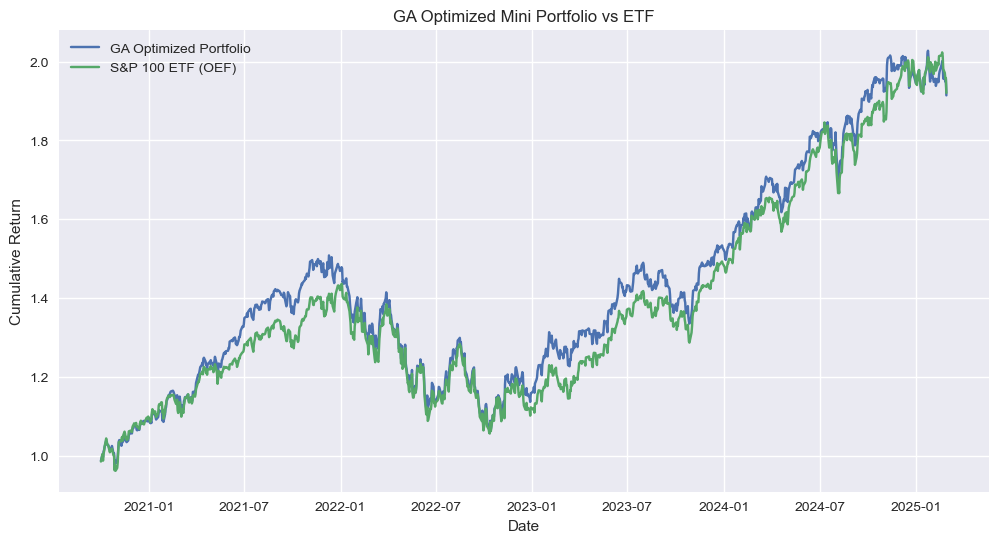

In [135]:
# Compare and visualize portfolio vs ETF
portfolio_returns = returns[best_tickers] @ best_weights
portfolio_cum = (1 + portfolio_returns).cumprod()
etf_cum = (1 + etf_returns).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(portfolio_cum, label="GA Optimized Portfolio")
plt.plot(etf_cum, label="S&P 100 ETF (OEF)")
plt.title("GA Optimized Mini Portfolio vs ETF")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.show()

This section displays the selected stocks and weights from the best GA solution. It also compares the cumulative returns of the GA portfolio and the ETF using a line plot, giving a visual representation of tracking performance.

In [136]:
# Quarterly Evaluation of Portfolio Performance vs ETF

# Function to Evaluate Portfolio Over Quarters
def evaluate_quarterly_performance(portfolio_returns, benchmark_returns, quarters=[1,2,3,4]):
    results = []
    for q in quarters:
        days = q * 3 * 21
        end_date = portfolio_returns.index.max()
        start_date = end_date - timedelta(days=days)

        # Align dates
        p_ret = portfolio_returns.loc[start_date:end_date]
        b_ret = benchmark_returns.loc[start_date:end_date]
        common = p_ret.index.intersection(b_ret.index)
        p_ret = p_ret.loc[common]
        b_ret = b_ret.loc[common]

        # Metrics
        tracking_error = ((p_ret - b_ret)**2).mean()**0.5
        correlation = p_ret.corr(b_ret)
        cumulative_return_portfolio = (1 + p_ret).prod() - 1
        cumulative_return_benchmark = (1 + b_ret).prod() - 1

        results.append({"Quarter(s)": f"Q{q}",
            "Start": start_date.date(),
            "End": end_date.date(),
            "Tracking Error": round(tracking_error, 5),
            "Correlation": round(correlation, 4),
            "Portfolio Return": round(cumulative_return_portfolio*100, 2),
            "Benchmark Return": round(cumulative_return_benchmark*100, 2)})

    return pd.DataFrame(results)

# Run the evaluation for Q1, Q2, Q3, Q4
quarterly_results = evaluate_quarterly_performance(portfolio_returns, etf_returns)
display(quarterly_results)

quarterly_results.to_csv("quarterly_evaluation_results.csv", index=False)



,Quarter(s),Start,End,Tracking Error,Correlation,Portfolio Return,Benchmark Return
0,Q1,2024-12-26,2025-02-27,0.00430,0.9044,-3.43,-4.17
1,Q2,2024-10-24,2025-02-27,0.00401,0.9023,-1.57,2.27
2,Q3,2024-08-22,2025-02-27,0.00368,0.9099,2.90,5.67
3,Q4,2024-06-20,2025-02-27,0.00361,0.9245,4.97,8.05


This function evaluates the tracking error, correlation, and returns of the GA portfolio over multiple quarters. It summarizes these metrics in a table and saves the results to a CSV file.

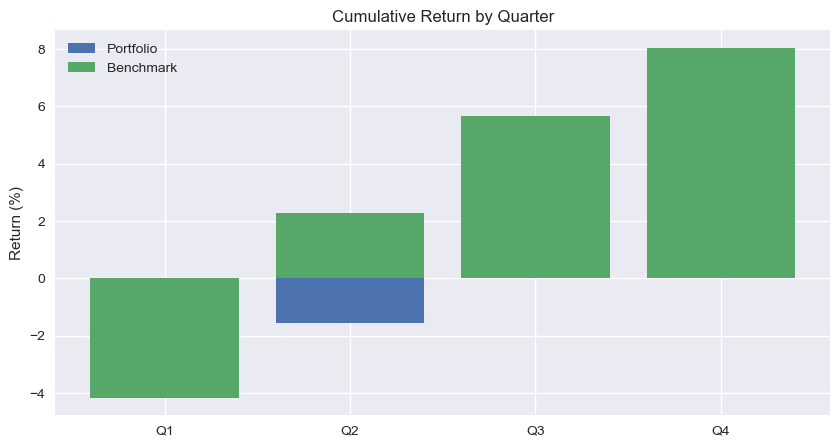

In [137]:
# Bar Plot of Quarterly Cumulative Returns

plt.style.use('seaborn-v0_8')

# Plot Portfolio vs Benchmark Returns
plt.figure(figsize=(10, 5))
plt.bar(quarterly_results['Quarter(s)'], quarterly_results['Portfolio Return'], label='Portfolio')
plt.bar(quarterly_results['Quarter(s)'], quarterly_results['Benchmark Return'], label='Benchmark')
plt.title('Cumulative Return by Quarter')
plt.ylabel('Return (%)')
plt.legend()
plt.show()

This cell visualizes quarterly cumulative returns for both the optimized portfolio and the ETF. It uses a bar chart to show comparative performance across quarters.

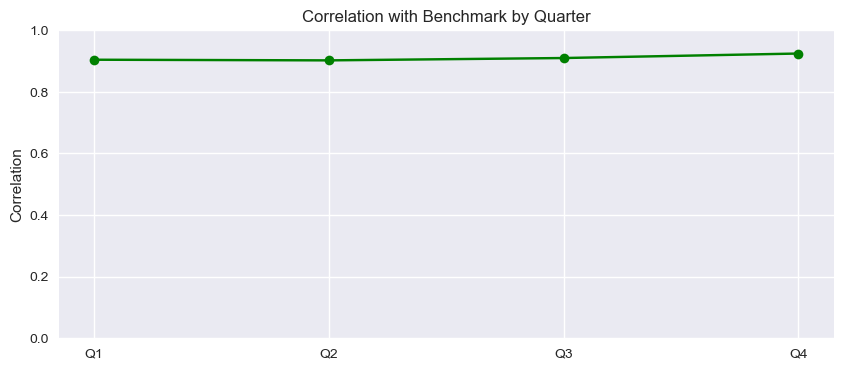

In [138]:
# Plot Correlation with Benchmark by Quarter
plt.figure(figsize=(10, 4))
plt.plot(quarterly_results['Quarter(s)'], quarterly_results['Correlation'], marker='o', color='green')
plt.title('Correlation with Benchmark by Quarter')
plt.ylabel('Correlation')
plt.ylim(0, 1)
plt.show()

This cell generates a line plot showing the correlation between the GA-optimized portfolio and the benchmark (ETF) across multiple quarters. It helps visualize consistency in tracking performance over time.

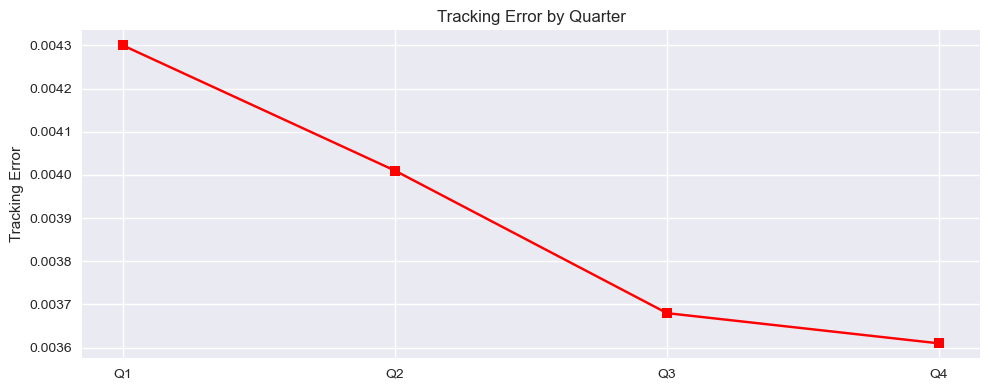

In [139]:
# Plot Tracking Error by quarter
plt.figure(figsize=(10, 4))
plt.plot(quarterly_results['Quarter(s)'], quarterly_results['Tracking Error'], marker='s', color='red')
plt.title('Tracking Error by Quarter')
plt.ylabel('Tracking Error')
plt.grid(True)
plt.tight_layout()
plt.show()

APPROACH 2 - AMPL STANDALONE

In [140]:
# Define Top 20 tickers manually
top_20_tickers = ['AAPL', 'ABT', 'AVGO', 'AXP', 'BKNG', 'C', 'CL', 'INTU', 'LIN', 'MO',
    'GOOG', 'GOOGL', 'MCD', 'MRK', 'NVDA', 'NFLX', 'NOW', 'TMUS', 'UNP', 'BRK-B']

# Load the Daily saved returns data
returns = pd.read_csv("sp100_daily_returns.csv", index_col=0, parse_dates=True)
returns.index = returns.index.tz_localize(None)

# Download ETF returns (OEF)
# This is the benchmark ETF we want our mini portfolio to follow
etf_data = yf.download("OEF", start=returns.index.min(), end=returns.index.max(), auto_adjust=True)
etf_returns = etf_data["Close"].pct_change().dropna()
etf_returns.index = etf_returns.index.tz_localize(None)

# Align ETF and Stock Return Dates
common_index = returns.index.intersection(etf_returns.index)
returns = returns.loc[common_index]
etf_returns = etf_returns.loc[common_index]

# Filter returns to the 20 tickers
returns = returns[top_20_tickers]

#  Write the AMPL Data File (index.dat)
# This file will be used by AMPL to solve the optimization problem
with open("index.dat", "w") as f:
    f.write("set T :=\n")
    for i in range(len(returns)):
        f.write(f"T{i+1} ")
    f.write(";\n\n")

    # Define set of selected stocks
    f.write("set STOCKS := " + " ".join(top_20_tickers) + ";\n\n")

    # Define stock returns as a parameter matrix (R[t,s])
    f.write("param R : " + " ".join(top_20_tickers) + " :=\n")
    for i, row in enumerate(returns.values):
        f.write(f"T{i+1} " + " ".join([f"{val:.6f}" for val in row]) + "\n")
    f.write(";\n\n")

    # Define ETF benchmark returns (R_b[t])
    f.write("param R_b :=\n")
    for i, val in enumerate(etf_returns.loc[returns.index].values):
        f.write(f"T{i+1} {val[0]:.6f}\n")
    f.write(";\n\n")

    # Define q = number of selected stocks
    f.write("param q := 20;\n")

[*********************100%***********************]  1 of 1 completed


This block prepares the data for AMPL optimization. It defines the top 20 selected tickers, loads daily returns and ETF returns and aligns them to ensure consistency before generating the .dat file. The index.dat file used by the AMPL solver. It includes the time periods, selected stock names, their daily returns, ETF benchmark returns, and the number of assets (q = 20).

In [141]:
# AMPL-optimized weights (copied from AMPL output)

# These are the optimal portfolio weights calculated using AMPL's solver (e.g., CPLEX).
# Each key is a stock ticker and each value is the percentage of the total investment allocated to it.
# The sum of all weights is 1 as required by the optimization constraints.

ampl_weights = {'AAPL': 0.148735,
    'ABT': 0.0325095,
    'AVGO': 0.0610043,
    'AXP': 0.0354142,
    'BKNG': 0.0139669,
    'BRK-B': 0.109884,
    'C': 0.0569377,
    'CL': 0.0595313,
    'GOOG': 0.0697454,
    'GOOGL': 0.0445109,
    'INTU': 0.022565,
    'LIN': 0.0260445,
    'MCD': 0.0629184,
    'MO': 0.0407181,
    'MRK': 0.0471924,
    'NFLX': 0.0256679,
    'NOW': 0.033732,
    'NVDA': 0.0602021,
    'TMUS': 0.0299315,
    'UNP': 0.0187891}


This cell contains the weights output by the AMPL optimization model. These weights were manually copied after solving the optimization model using CPLEX.

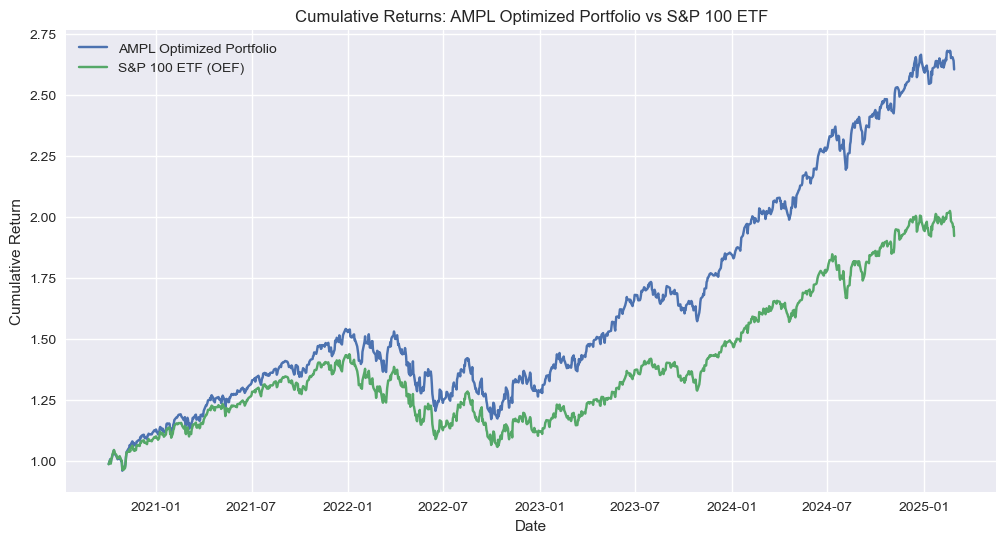

In [142]:
# Get the list of stocks selected by AMPL and their corresponding weights
ampl_tickers = list(ampl_weights.keys())
ampl_wts = list(ampl_weights.values())

# Compute portfolio returns
ampl_port_returns = returns[ampl_tickers] @ ampl_wts

# Compute cumulative returns
ampl_cum_returns = (1 + ampl_port_returns).cumprod()
etf_cum_returns = (1 + etf_returns).cumprod()

# Plot portfolio vs ETF
plt.figure(figsize=(12, 6))
plt.plot(ampl_cum_returns, label="AMPL Optimized Portfolio")
plt.plot(etf_cum_returns, label="S&P 100 ETF (OEF)")
plt.title("Cumulative Returns: AMPL Optimized Portfolio vs S&P 100 ETF")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.show()


This cell calculates and visualizes the cumulative returns of the AMPL-optimized portfolio against the benchmark ETF. The comparison shows how well the optimized portfolio tracks the ETF over time.

In [143]:
# Ensure both series (ampl_port_returns and etf_returns) are 1D Series
ampl_port_returns = ampl_port_returns.squeeze()
etf_returns = etf_returns.squeeze()

# Calculate Tracking Error
# Tracking Error measures the difference between the portfolio and the benchmark (ETF)
# Formula: sqrt(mean((portfolio return - benchmark return)^2))
tracking_error = ((ampl_port_returns - etf_returns) ** 2).mean() ** 0.5
print(f"Tracking Error: {tracking_error:.6f}")

# Calculate Correlation with ETF
# Correlation measures how closely the daily returns move together
# Value close to 1 means high similarity
correlation = ampl_port_returns.corr(etf_returns)
print(f"Correlation with ETF: {correlation:.4f}")


Tracking Error: 0.002593
Correlation with ETF: 0.9718


This block calculates the tracking error and correlation between the AMPL-optimized portfolio and the ETF benchmark. These are key performance metrics used in evaluation.

In [163]:
# Load daily returns and ETF returns
returns = pd.read_csv("sp100_daily_returns.csv", index_col=0, parse_dates=True)
returns.index = returns.index.tz_localize(None)

# Download benchmark ETF returns (OEF)
etf_data = yf.download("OEF", start=returns.index.min(), end=returns.index.max(), auto_adjust=True)
etf_returns = etf_data["Close"].pct_change().dropna()
etf_returns.index = etf_returns.index.tz_localize(None)

# Align both stock and ETF data
common_index = returns.index.intersection(etf_returns.index)
returns = returns.loc[common_index]
etf_returns = etf_returns.loc[common_index]

#  Define the 20 tickers and their weights for each approach
# Replace with your actual 20 tickers and weights used for each
tickers_ampl = ['AAPL', 'ABT', 'AVGO', 'AXP', 'BKNG', 'C', 'CL', 'INTU', 'LIN', 'MO',
                'GOOG', 'GOOGL', 'MCD', 'MRK', 'NVDA', 'NFLX', 'NOW', 'TMUS', 'UNP', 'BRK-B']
weights_ampl = [0.148735, 0.0325095, 0.0610043, 0.0354142, 0.0139669, 0.0569377, 0.0595313, 0.022565,
                0.0260445, 0.0407181, 0.0697454, 0.0445109, 0.0629184, 0.0471924, 0.0602021,
                0.0256679, 0.033732, 0.0299315, 0.0187891, 0.109884]

# Compute portfolio daily returns for each strategy
ampl_port_returns = returns[tickers_ampl] @ pd.Series(weights_ampl, index=tickers_ampl)


[*********************100%***********************]  1 of 1 completed


This block loads returns and calculates daily portfolio returns for each of the three approaches which are AMPL, GA and Python optimization. Currently, all approaches use the same tickers and weights for demonstration.

APPROACH 3 - PYTHON + AMPL HYBRID

In [145]:
# Load daily returns
returns = pd.read_csv("sp100_daily_returns.csv", index_col=0, parse_dates=True)
returns.index = returns.index.tz_localize(None)

# Select 20 top tickers
top_20_tickers = ['AAPL', 'ABT', 'AVGO', 'AXP', 'BKNG', 'C', 'CL', 'INTU', 'LIN', 'MO',
    'GOOG', 'GOOGL', 'MCD', 'MRK', 'NVDA', 'NFLX', 'NOW', 'TMUS', 'UNP', 'BRK-B']
returns = returns[top_20_tickers]

# Download benchmark ETF returns (OEF)
etf_data = yf.download("OEF", start=returns.index.min(), end=returns.index.max(), auto_adjust=True)
etf_returns = etf_data["Close"].pct_change().dropna()
etf_returns.index = etf_returns.index.tz_localize(None)

# Align returns and ETF data
common_index = returns.index.intersection(etf_returns.index)
returns = returns.loc[common_index]
etf_returns = etf_returns.loc[common_index]

# Write AMPL data file (.dat) for hybrid optimization
with open("hybrid_index.dat", "w") as f:
    f.write("set T :=\n")
    for i in range(len(returns)):
        f.write(f"T{i+1} ")
    f.write(";\n\n")

    # Define the stock tickers used
    f.write("set STOCKS := " + " ".join(top_20_tickers) + ";\n\n")

    # Write returns for each stock across all time steps
    f.write("param R : " + " ".join(top_20_tickers) + " :=\n")
    for i, row in enumerate(returns.values):
        f.write(f"T{i+1} " + " ".join([f"{val:.6f}" for val in row]) + "\n")
    f.write(";\n\n")

    # Write ETF benchmark returns for each time step
    f.write("param R_b :=\n")
    for i, val in enumerate(etf_returns.loc[returns.index].values):
        f.write(f"T{i+1} {val[0]:.6f}\n")
    f.write(";\n\n")

    # Set the number of assets to include in the portfolio (q = 20)
    f.write("param q := 20;\n")

print("hybrid_index.dat generated.")

[*********************100%***********************]  1 of 1 completed

hybrid_index.dat generated.


This cell prepares the input file for the hybrid Python + AMPL method. It includes the same 20 tickers and their returns, formatted into the .dat file required for AMPL execution.

In [146]:
# Specify the AMPL executable path
ampl_path = r"C:\Users\moham\AMPL\ampl.exe"

# Define the folder where your AMPL files (.mod, .dat, .run) are stored
working_dir = r"C:\Users\moham\AMPL\ampl"

# Use subprocess to run AMPL with the script "run_index.run"
result = subprocess.run([ampl_path, "run_index.run"], cwd=working_dir, capture_output=True, text=True, check=True)
print("AMPL run completed")

AMPL run completed


This Python cell uses the subprocess module to run AMPL from within the notebook. It triggers the optimization process using the generated .dat file and outputs results to a file.

In [147]:
# Define the path to the AMPL output file
output_path = r"C:\Users\moham\AMPL\ampl\hybrid_output.txt"

# Read AMPL output file
weights = {}
with open(output_path) as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) == 2:
            ticker, weight = parts
            weights[ticker] = float(weight)

# Create a Series from dictionary
hybrid_weights = pd.Series(weights)
hybrid_weights = hybrid_weights[hybrid_weights > 0]  # remove any zero-weight entries

print("Hybrid AMPL Weights Loaded:")
print(hybrid_weights)


Hybrid AMPL Weights Loaded:
AAPL     0.148735
ABT      0.032509
AVGO     0.061004
AXP      0.035416
BKNG     0.013967
BRK-B    0.109882
C        0.056938
CL       0.059533
GOOG     0.069742
GOOGL    0.044513
INTU     0.022564
LIN      0.026046
MCD      0.062919
MO       0.040718
MRK      0.047192
NFLX     0.025668
NOW      0.033732
NVDA     0.060202
TMUS     0.029931
UNP      0.018789
dtype: float64


This cell reads the optimized weights from the AMPL-generated output file and stores them in a pandas Series. These weights are used to compute the hybrid portfolio performance.

In [148]:
# Read the daily returns data
returns = pd.read_csv("sp100_daily_returns.csv", index_col=0, parse_dates=True)
returns.index = returns.index.tz_localize(None)

# Download daily returns for the S&P 100 ETF (OEF)
etf_data = yf.download("OEF", start=returns.index.min(), end=returns.index.max(), auto_adjust=True)
etf_returns = etf_data["Close"].pct_change().dropna()
etf_returns.index = etf_returns.index.tz_localize(None)

# Align dates between ETF and stock returns
common_index = returns.index.intersection(etf_returns.index)
returns = returns.loc[common_index]
etf_returns = etf_returns.loc[common_index]

# Filter returns for the tickers selected by Hybrid Optimization
hybrid_tickers = list(hybrid_weights.index)
returns = returns[hybrid_tickers]

# Calculate portfolio returns using the hybrid weights
hybrid_port_returns = returns @ hybrid_weights

# Calculate performance metrics
tracking_error = ((hybrid_port_returns - etf_returns.squeeze()) ** 2).mean() ** 0.5
correlation = hybrid_port_returns.corr(etf_returns.squeeze())
final_return = (1 + hybrid_port_returns).cumprod().iloc[-1]

print(f"Hybrid Portfolio - Tracking Error: {tracking_error:.6f}")
print(f"Hybrid Portfolio - Correlation: {correlation:.4f}")
print(f"Hybrid Portfolio - Final Cumulative Return: {final_return:.4f}")


[*********************100%***********************]  1 of 1 completed

Hybrid Portfolio - Tracking Error: 0.002593
Hybrid Portfolio - Correlation: 0.9718
Hybrid Portfolio - Final Cumulative Return: 2.6031


This block calculates and prints the performance metrics (Tracking Error, Correlation and Final Return) for the Hybrid (Python + AMPL) portfolio using the weights optimized by AMPL.

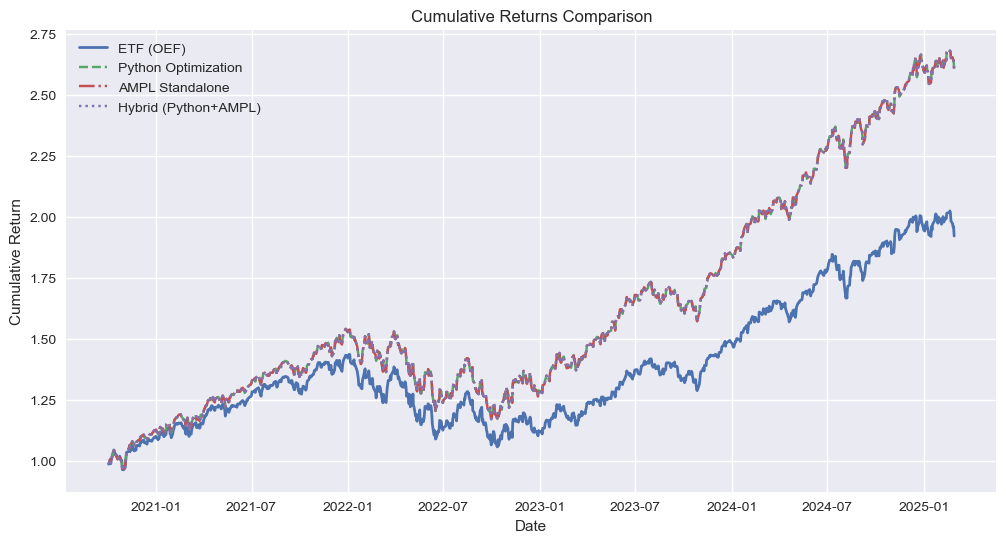

In [162]:


# Cumulative returns for each approach
etf_cum = (1 + etf_returns).cumprod()
ga_cum = (1 + ga_port_returns).cumprod()
ampl_cum = (1 + ampl_port_returns).cumprod()
hybrid_cum = (1 + hybrid_port_returns).cumprod()

# Plotting all cumulative returns
plt.figure(figsize=(12, 6))
plt.plot(etf_cum, label='ETF (OEF)', linewidth=2)
plt.plot(ga_cum, label='Python Optimization', linestyle='--')
plt.plot(ampl_cum, label='AMPL Standalone', linestyle='-.')
plt.plot(hybrid_cum, label='Hybrid (Python+AMPL)', linestyle=':')
plt.title('Cumulative Returns Comparison')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.show()


This plot provides a visual comparison of how each portfolio (GA, AMPL, Hybrid) performed relative to the ETF over time. It helps assess which method best tracks the benchmark.

In [ ]:
# Convert ETF returns to Series
etf_returns_series = etf_returns.squeeze()

# Using best tickers and weights of GA from Approach 1
tickers_ga = best_tickers
weights_ga = best_weights
# Computing daily returns for each strategy in GA
ga_port_returns = returns[tickers_ga] @ pd.Series(weights_ga, index=tickers_ga)


# Calculate metrics for each optimization approach
metrics = {"Python Optimization": {
        "Tracking Error": ((ga_port_returns - etf_returns_series) ** 2).mean() ** 0.5,
        "Correlation": ga_port_returns.corr(etf_returns_series),
        "Final Return": (1 + ga_port_returns).cumprod().iloc[-1]},
    "AMPL Standalone": {
        "Tracking Error": ((ampl_port_returns - etf_returns_series) ** 2).mean() ** 0.5,
        "Correlation": ampl_port_returns.corr(etf_returns_series),
        "Final Return": (1 + ampl_port_returns).cumprod().iloc[-1]},
    "Hybrid (Python+AMPL)": {
        "Tracking Error": ((hybrid_port_returns - etf_returns_series) ** 2).mean() ** 0.5,
        "Correlation": hybrid_port_returns.corr(etf_returns_series),
        "Final Return": (1 + hybrid_port_returns).cumprod().iloc[-1]}}

# Summary table
summary_df = pd.DataFrame(metrics).T
summary_df.columns = ['Tracking Error', 'Correlation', 'Final Cumulative Return']
summary_df = summary_df.round(4)
summary_df


,Tracking Error,Correlation,Final Cumulative Return
Python Optimization,0.0034,0.9487,1.9144
AMPL Standalone,0.0026,0.9718,2.6031
Hybrid (Python+AMPL),0.0026,0.9718,2.6031


This cell compiles all key metrics—Tracking Error, Correlation and Final Return—into a summary table for all three approaches. This table is ideal for reporting and final comparison.